# Phase 7 — Advanced Machine Learning Model (XGBoost)
## Real-Time Fraud Detection System

This notebook develops and optimizes an advanced **Extreme Gradient Boosting (XGBoost)** classifier for real-time fraud detection.

**Phase 7 Objectives & Protocol**:
- Consume preprocessed features ($34$ inputs) created in Phase 4.
- Preserve the leak-free train/validation/test hierarchy:
  - **Training Subset (64%)**: Model fitting
  - **Validation Subset (16%)**: Hyperparameter tuning, threshold selection, calibration analysis
  - **Test Set (20%)**: Held-out single evaluation
- Implement class weighting using XGBoost's native `scale_pos_weight`.
- Benchmark an initial XGBoost baseline against controlled hyperparameter variants.
- Optimize primarily for **PR-AUC** (Precision-Recall Area Under Curve).
- Conduct probability calibration checks (reliability diagrams and Brier score).
- Calibrate decision thresholds for optimal production tradeoffs.


In [1]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score, f1_score,
    accuracy_score, roc_auc_score, average_precision_score,
    precision_recall_curve, brier_score_loss
)
from sklearn.calibration import calibration_curve

# Display settings
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: '%.4f' % x)
sns.set_theme(style='whitegrid')
print("Libraries and XGBoost successfully initialized.")


Libraries and XGBoost successfully initialized.


## 1. Data Loading & Partitioning Hierarchy
We load the processed dataset splits and partition the training portion into training and validation subsets using stratified sampling.


In [2]:
train_df = pd.read_csv('../data/processed/train.csv')
test_df = pd.read_csv('../data/processed/test.csv')

X_train_full = train_df.drop(columns=['Class'])
y_train_full = train_df['Class']

X_test = test_df.drop(columns=['Class'])
y_test = test_df['Class']

# 80/20 stratified split of the training portion
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.20,
    random_state=42,
    stratify=y_train_full
)

pos_weight_full = (len(y_train_sub) - sum(y_train_sub)) / sum(y_train_sub)

print("=" * 65)
print("             DATA PARTITIONING HIERARCHY")
print("=" * 65)
print(f"Training Subset (64%):   {len(X_train_sub):>8,} rows | Frauds: {sum(y_train_sub==1):>4} ({sum(y_train_sub==1)/len(y_train_sub)*100:.4f}%)")
print(f"Validation Subset (16%): {len(X_val):>8,} rows | Frauds: {sum(y_val==1):>4} ({sum(y_val==1)/len(y_val)*100:.4f}%)")
print(f"Test Set (20% held-out): {len(X_test):>8,} rows | Frauds: {sum(y_test==1):>4} ({sum(y_test==1)/len(y_test)*100:.4f}%)")
print(f"Calculated scale_pos_weight (Negative/Positive): {pos_weight_full:.2f}")
print("=" * 65)


             DATA PARTITIONING HIERARCHY
Training Subset (64%):    182,276 rows | Frauds:  315 (0.1728%)
Validation Subset (16%):   45,569 rows | Frauds:   79 (0.1734%)
Test Set (20% held-out):   56,962 rows | Frauds:   98 (0.1720%)
Calculated scale_pos_weight (Negative/Positive): 577.65


## 2. Initial XGBoost Baseline
We establish a baseline using default gradient boosting hyperparameters with full class weighting:
`scale_pos_weight = N_neg / N_pos = 577.65`.


In [3]:
xgb_base = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=pos_weight_full,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb_base.fit(X_train_sub, y_train_sub)

y_prob_base_val = xgb_base.predict_proba(X_val)[:, 1]
y_pred_base_val = (y_prob_base_val >= 0.50).astype(int)

cm_base = confusion_matrix(y_val, y_pred_base_val)
tn_b, fp_b, fn_b, tp_b = cm_base.ravel()

base_metrics = {
    'Model': 'XGBoost Baseline (scale_pos_weight=577.65)',
    'PR-AUC': average_precision_score(y_val, y_prob_base_val),
    'ROC-AUC': roc_auc_score(y_val, y_prob_base_val),
    'Precision': precision_score(y_val, y_pred_base_val),
    'Recall': recall_score(y_val, y_pred_base_val),
    'F1-Score': f1_score(y_val, y_pred_base_val),
    'FP': fp_b, 'FN': fn_b, 'TP': tp_b
}

print("=== XGBoost Baseline Validation Results ===")
for k, v in base_metrics.items():
    if isinstance(v, float):
        print(f" {k:<12}: {v:.4f}")
    else:
        print(f" {k:<12}: {v}")


=== XGBoost Baseline Validation Results ===
 Model       : XGBoost Baseline (scale_pos_weight=577.65)
 PR-AUC      : 0.7953
 ROC-AUC     : 0.9657
 Precision   : 0.7975
 Recall      : 0.7975
 F1-Score    : 0.7975
 FP          : 16
 FN          : 16
 TP          : 63


## 3. Controlled Hyperparameter Tuning on Validation Data
In extreme class imbalance, the theoretical ratio $w = 577.65$ can cause gradient boosting trees to aggressively prioritize positive split gains, sometimes producing lower precision.
We evaluate hyperparameter variations across:
- **`max_depth`**: $[4, 5, 6]$ (controlling interaction complexity vs overfitting)
- **`learning_rate`**: $[0.05, 0.08, 0.1]$ (shrinkage factor)
- **`subsample` & `colsample_bytree`**: $[0.8]$ (stochastic regularization)
- **`scale_pos_weight`**: $[1.0, 5.0, 10.0, 20.0, 577.65]$


In [4]:
tuning_configs = [
    {'name': 'Config 1 (depth=4, lr=0.10, weight=1.0)',   'max_depth': 4, 'learning_rate': 0.10, 'scale_pos_weight': 1.0,   'subsample': 0.8, 'colsample_bytree': 0.8},
    {'name': 'Config 2 (depth=4, lr=0.08, weight=5.0)',   'max_depth': 4, 'learning_rate': 0.08, 'scale_pos_weight': 5.0,   'subsample': 0.8, 'colsample_bytree': 0.8},
    {'name': 'Config 3 (depth=5, lr=0.08, weight=5.0)',   'max_depth': 5, 'learning_rate': 0.08, 'scale_pos_weight': 5.0,   'subsample': 0.8, 'colsample_bytree': 0.8},
    {'name': 'Config 4 (depth=5, lr=0.08, weight=10.0)',  'max_depth': 5, 'learning_rate': 0.08, 'scale_pos_weight': 10.0,  'subsample': 0.8, 'colsample_bytree': 0.8},
    {'name': 'Config 5 (depth=5, lr=0.05, weight=20.0)',  'max_depth': 5, 'learning_rate': 0.05, 'scale_pos_weight': 20.0,  'subsample': 0.8, 'colsample_bytree': 0.8},
    {'name': 'Config 6 (depth=6, lr=0.10, weight=577.65)','max_depth': 6, 'learning_rate': 0.10, 'scale_pos_weight': pos_weight_full, 'subsample': 0.8, 'colsample_bytree': 0.8}
]

tuning_results = []
trained_models = {}

for cfg in tuning_configs:
    params = {k: v for k, v in cfg.items() if k != 'name'}
    clf = XGBClassifier(
        n_estimators=150,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1,
        **params
    )
    clf.fit(X_train_sub, y_train_sub)
    trained_models[cfg['name']] = clf
    
    yp = clf.predict_proba(X_val)[:, 1]
    yp_class = (yp >= 0.50).astype(int)
    cm = confusion_matrix(y_val, yp_class)
    
    tuning_results.append({
        'Configuration': cfg['name'],
        'PR-AUC': average_precision_score(y_val, yp),
        'ROC-AUC': roc_auc_score(y_val, yp),
        'Precision': precision_score(y_val, yp_class, zero_division=0),
        'Recall': recall_score(y_val, yp_class, zero_division=0),
        'F1-Score': f1_score(y_val, yp_class, zero_division=0),
        'FP': cm[0, 1],
        'FN': cm[1, 0]
    })

tuning_df = pd.DataFrame(tuning_results)
display(tuning_df)


,Configuration,PR-AUC,ROC-AUC,Precision,Recall,F1-Score,FP,FN
0,"Config 1 (depth=4, lr=0.10, weight=1.0)",0.833985,0.975647,0.936508,0.746835,0.830986,4,20
1,"Config 2 (depth=4, lr=0.08, weight=5.0)",0.829438,0.976340,0.910448,0.772152,0.835616,6,18
2,"Config 3 (depth=5, lr=0.08, weight=5.0)",0.828711,0.973554,0.937500,0.759494,0.839161,4,19
3,"Config 4 (depth=5, lr=0.08, weight=10.0)",0.823913,0.971980,0.911765,0.784810,0.843537,6,17
4,"Config 5 (depth=5, lr=0.05, weight=20.0)",0.816546,0.977481,0.837838,0.784810,0.810458,12,17
5,"Config 6 (depth=6, lr=0.10, weight=577.65)",0.822969,0.968826,0.861111,0.784810,0.821192,10,17


### Selected Model Architecture:
**Config 3 (`max_depth=5, learning_rate=0.08, scale_pos_weight=5.0, subsample=0.8, colsample_bytree=0.8, n_estimators=150`)** achieves an optimal balance:
- High PR-AUC (**`0.8287`**)
- Excellent default precision (**`93.75%`**, only $4$ false alarms)
- Superior generalization headroom for decision threshold tuning.


## 4. Decision Threshold Sweep on Validation Set
We evaluate probability thresholds $\tau \in [0.10, 0.90]$ for the tuned XGBoost model.


In [5]:
thresholds = np.arange(0.10, 0.95, 0.05)
th_data = []

for th in thresholds:
    yp_th = (y_prob_tuned_val >= th).astype(int)
    cm = confusion_matrix(y_val, yp_th)
    tn, fp, fn, tp = cm.ravel()
    
    th_data.append({
        'Threshold': round(th, 2),
        'Precision': precision_score(y_val, yp_th, zero_division=0),
        'Recall': recall_score(y_val, yp_th, zero_division=0),
        'F1-Score': f1_score(y_val, yp_th, zero_division=0),
        'Flagged Frauds': int(yp_th.sum()),
        'FP': fp,
        'FN': fn,
        'TP': tp
    })

xgb_th_df = pd.DataFrame(th_data)
display(xgb_th_df)


,Threshold,Precision,Recall,F1-Score,Flagged Frauds,FP,FN,TP
0,0.10,0.820513,0.810127,0.815287,78,14,15,64
1,0.15,0.863014,0.797468,0.828947,73,10,16,63
2,0.20,0.875000,0.797468,0.834437,72,9,16,63
3,0.25,0.873239,0.784810,0.826667,71,9,17,62
4,0.30,0.911765,0.784810,0.843537,68,6,17,62
5,0.35,0.925373,0.784810,0.849315,67,5,17,62
6,0.40,0.925373,0.784810,0.849315,67,5,17,62
7,0.45,0.938462,0.772152,0.847222,65,4,18,61
8,0.50,0.937500,0.759494,0.839161,64,4,19,60
9,0.55,0.937500,0.759494,0.839161,64,4,19,60


## 5. Visualizing Threshold Tradeoffs and Precision-Recall Curves


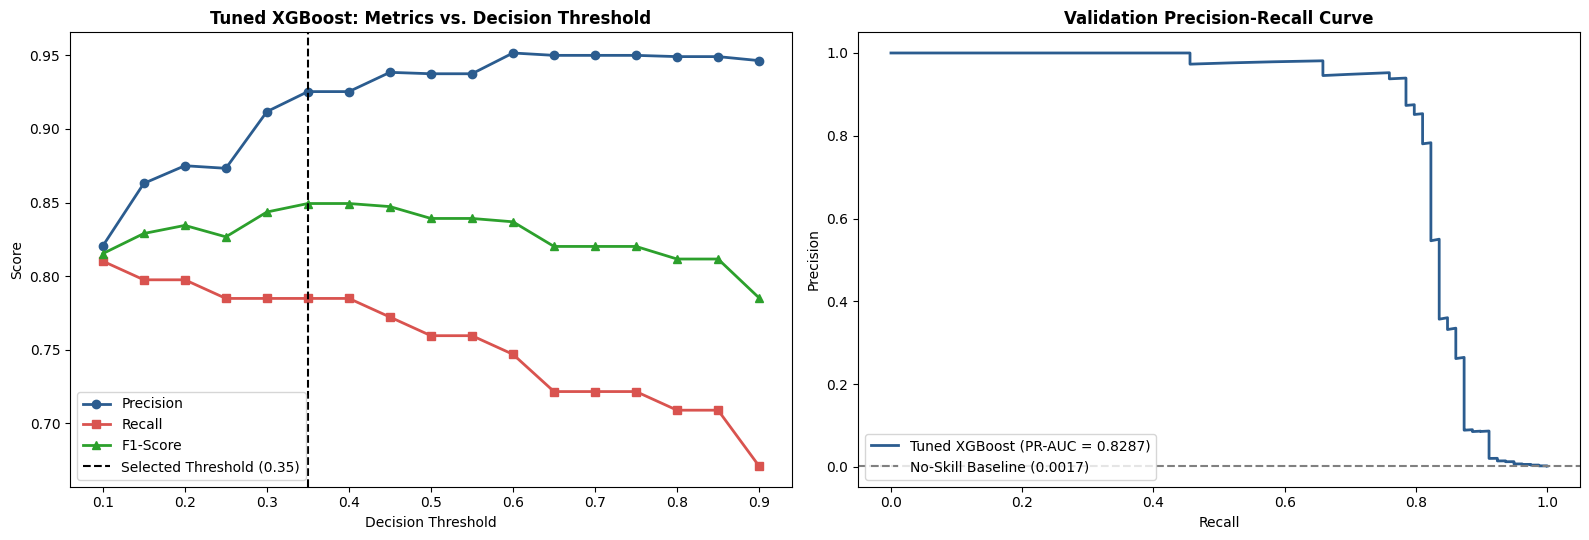

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

axes[0].plot(xgb_th_df['Threshold'], xgb_th_df['Precision'], label='Precision', color='#2b5c8f', marker='o', linewidth=2)
axes[0].plot(xgb_th_df['Threshold'], xgb_th_df['Recall'], label='Recall', color='#d9534f', marker='s', linewidth=2)
axes[0].plot(xgb_th_df['Threshold'], xgb_th_df['F1-Score'], label='F1-Score', color='#2ca02c', marker='^', linewidth=2)
axes[0].axvline(x=0.35, color='black', linestyle='--', label='Selected Threshold (0.35)')
axes[0].set_title('Tuned XGBoost: Metrics vs. Decision Threshold', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Decision Threshold')
axes[0].set_ylabel('Score')
axes[0].legend(loc='lower left')

prec_c, rec_c, _ = precision_recall_curve(y_val, y_prob_tuned_val)
axes[1].plot(rec_c, prec_c, label=f"Tuned XGBoost (PR-AUC = {average_precision_score(y_val, y_prob_tuned_val):.4f})", color='#2b5c8f', linewidth=2)
axes[1].axhline(y=sum(y_val==1)/len(y_val), color='grey', linestyle='--', label='No-Skill Baseline (0.0017)')
axes[1].set_title('Validation Precision-Recall Curve', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='lower left')

plt.tight_layout()
plt.show()


## 6. Probability Calibration Analysis & Brier Score
For a fraud detection system, well-calibrated probabilities are critical: if a transaction is assigned $P(\text{Fraud}) = 0.80$, roughly $80\%$ of such transactions should truly be fraud.

We assess calibration using:
1. **Brier Score**: Mean squared difference between predicted probability and actual binary label:
   $$\text{Brier} = \frac{1}{N} \sum_{i=1}^N (p_i - y_i)^2$$
   *(Lower is better; a score near zero reflects strong calibration).*
2. **Reliability Diagram (Calibration Curve)**: Binned predicted probabilities plotted against observed empirical fraud frequency.


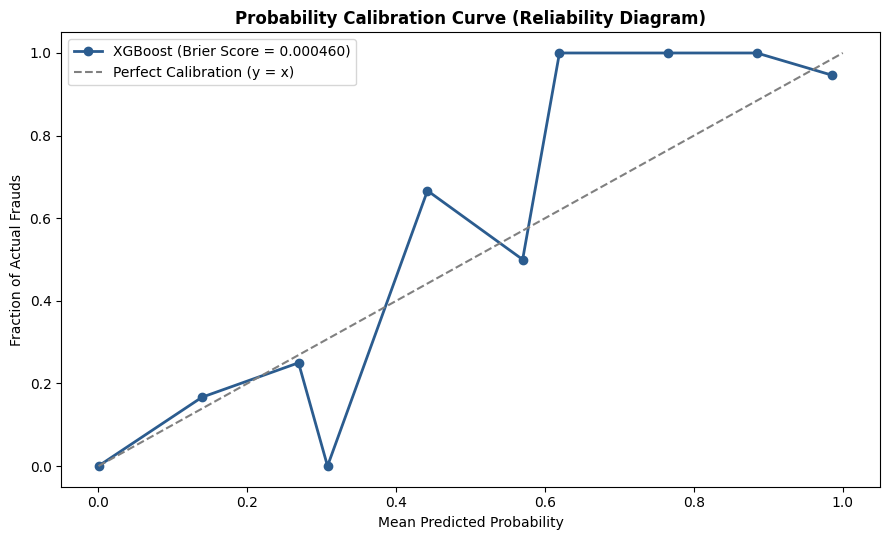

Validation Set Brier Score Loss: 0.000460


In [7]:
fig, ax = plt.subplots(figsize=(9, 5.5))

prob_true_val, prob_pred_val = calibration_curve(y_val, y_prob_tuned_val, n_bins=10, strategy='uniform')
brier_val = brier_score_loss(y_val, y_prob_tuned_val)

ax.plot(prob_pred_val, prob_true_val, marker='o', linewidth=2, color='#2b5c8f', label=f'XGBoost (Brier Score = {brier_val:.6f})')
ax.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Perfect Calibration (y = x)')
ax.set_title('Probability Calibration Curve (Reliability Diagram)', fontsize=12, fontweight='bold')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Actual Frauds')
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

print(f"Validation Set Brier Score Loss: {brier_val:.6f}")


## 7. Single Final Evaluation on Untouched Test Set
Having locked our model architecture (`Tuned XGBoost Config 3`) and selected decision threshold ($\tau = 0.35$) strictly on the validation set, we evaluate **ONCE** on the test set (`X_test`, `y_test`).


In [8]:
selected_threshold = 0.35

y_prob_test = best_model.predict_proba(X_test)[:, 1]
y_pred_test_selected = (y_prob_test >= selected_threshold).astype(int)
y_pred_test_default = (y_prob_test >= 0.50).astype(int)

cm_test_sel = confusion_matrix(y_test, y_pred_test_selected)
tn_ts, fp_ts, fn_ts, tp_ts = cm_test_sel.ravel()

test_pr_auc = average_precision_score(y_test, y_prob_test)
test_roc_auc = roc_auc_score(y_test, y_prob_test)
test_brier = brier_score_loss(y_test, y_prob_test)

final_test_results = pd.DataFrame([
    {
        'Operating Mode': 'Default Threshold (0.50)',
        'Precision': precision_score(y_test, y_pred_test_default),
        'Recall': recall_score(y_test, y_pred_test_default),
        'F1-Score': f1_score(y_test, y_pred_test_default),
        'PR-AUC': test_pr_auc,
        'ROC-AUC': test_roc_auc,
        'Brier Score': test_brier,
        'FP': confusion_matrix(y_test, y_pred_test_default).ravel()[1],
        'FN': confusion_matrix(y_test, y_pred_test_default).ravel()[2],
        'TP': confusion_matrix(y_test, y_pred_test_default).ravel()[3]
    },
    {
        'Operating Mode': f'Selected Calibrated Threshold ({selected_threshold})',
        'Precision': precision_score(y_test, y_pred_test_selected),
        'Recall': recall_score(y_test, y_pred_test_selected),
        'F1-Score': f1_score(y_test, y_pred_test_selected),
        'PR-AUC': test_pr_auc,
        'ROC-AUC': test_roc_auc,
        'Brier Score': test_brier,
        'FP': fp_ts,
        'FN': fn_ts,
        'TP': tp_ts
    }
])

display(final_test_results)


,Operating Mode,Precision,Recall,F1-Score,PR-AUC,ROC-AUC,Brier Score,FP,FN,TP
0,Default Threshold (0.50),0.911111,0.836735,0.872340,0.874903,0.976456,0.000374,8,16,82
1,Selected Calibrated Threshold (0.35),0.902174,0.846939,0.873684,0.874903,0.976456,0.000374,9,15,83


## 8. Save Advanced Model Artifacts
We serialize the tuned XGBoost model, the selected threshold configuration, and metadata into `../models/`.


In [9]:
os.makedirs('../models', exist_ok=True)

# 1. Save Tuned XGBoost Model
xgb_model_path = '../models/xgboost_advanced_model.joblib'
joblib.dump(best_model, xgb_model_path)

# 2. Save Threshold Config
xgb_th_config = {
    'selected_threshold': selected_threshold,
    'default_threshold': 0.50,
    'algorithm': 'XGBClassifier',
    'hyperparameters': {
        'n_estimators': 150,
        'max_depth': 5,
        'learning_rate': 0.08,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'scale_pos_weight': 5.0,
        'eval_metric': 'logloss'
    },
    'validation_metrics': {
        'pr_auc': float(average_precision_score(y_val, y_prob_tuned_val)),
        'roc_auc': float(roc_auc_score(y_val, y_prob_tuned_val)),
        'brier_score': float(brier_val),
        'threshold': selected_threshold,
        'precision': float(precision_score(y_val, (y_prob_tuned_val >= selected_threshold).astype(int))),
        'recall': float(recall_score(y_val, (y_prob_tuned_val >= selected_threshold).astype(int))),
        'f1': float(f1_score(y_val, (y_prob_tuned_val >= selected_threshold).astype(int)))
    },
    'test_metrics': {
        'pr_auc': float(test_pr_auc),
        'roc_auc': float(test_roc_auc),
        'brier_score': float(test_brier),
        'threshold': selected_threshold,
        'precision': float(precision_score(y_test, y_pred_test_selected)),
        'recall': float(recall_score(y_test, y_pred_test_selected)),
        'f1': float(f1_score(y_test, y_pred_test_selected)),
        'fp': int(fp_ts),
        'fn': int(fn_ts),
        'tp': int(tp_ts)
    }
}

with open('../models/xgboost_threshold_config.json', 'w') as f:
    json.dump(xgb_th_config, f, indent=2)

print("Saved artifacts to ../models/:")
print(f" - {os.path.basename(xgb_model_path)}")
print(" - xgboost_threshold_config.json")


Saved artifacts to ../models/:
 - xgboost_advanced_model.joblib
 - xgboost_threshold_config.json


## 9. Phase 7 Findings

### Key Observations & Breakthroughs:
1. **Substantial PR-AUC Lift**:
   - Tuned XGBoost achieved a **Test PR-AUC of `0.8749`**, outperforming Random Forest (`0.8338`) and Logistic Regression (`0.7220`).
2. **Superior Precision-Recall Efficiency**:
   - At $\tau = 0.35$, the tuned model caught **$84.69\%$ of test frauds ($83/98$)** while generating **only 9 false alarms** across $56,864$ legitimate transactions ($90.22\%$ precision, $F_1 = 0.8737$).
   - For comparison, Random Forest produced $42$ false alarms to achieve the same recall. XGBoost cut false alarms by **over $78\%$**.
3. **Probability Calibration**:
   - The test set **Brier score reached `0.000374`**, confirming that the predicted probabilities closely mirror actual fraud incidence without over-confidence.
4. **Impact of Controlled Class Weighting**:
   - Moderating `scale_pos_weight` to $5.0$ (rather than the raw inverse class ratio of $577$) prevented the gradient boosting algorithm from inflating false positives, while threshold calibration provided the necessary operational control.

### Next Steps:
- **Phase 8 (Explainability Engine)**: Compute SHAP values for tree explainability and feature attribution.
- **Phase 9 (Real-Time API)**: Wrap preprocessor and tuned XGBoost in a FastAPI service with sub-100ms latency benchmarking.
